# 04 — Full context-aware model (single condition, gates logged)

Trains ablation condition 8 (conv + temp + ret) at SMOKE settings on fold 0,
logs the per-instance Stage-4 gate values, and verifies checkpoint
save/reload. Also runs overfit-16 with all channels active.

**Every number below is SMOKE.**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from leische import data as D
from leische import evaluate as E
from leische import train as T
from leische.encoders import Tokenize
from leische.model import ContextAwareSarcasmModel
from leische.nbsupport import bootstrap

cfg, df, corpus, card, gate = bootstrap(config="configs/smoke.yaml", need_corpus=True,
                                        use_conv=True, use_temp=True, use_ret=True,
                                        run_name="smoke-full")
SMOKE = cfg.tag()
folds = D.load_folds(cfg.folds_file(), card)
device = torch.device("cuda")

C:\Users\Gio\Documents\GitHub\leische\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 SMOKE MODE — every number in this notebook is a harness or
 architecture check on the pilot export, NOT a reportable result.
dataset identity: {'dataset_version': 'v1', 'prompt_version': 'sarc-v1', 'uyam_commit': '69d0affaca157edaf64e617d21e8ae752c9343fa'}
rows: 100  sarcastic: 8  corpus: loaded

§10 data-readiness gate:
  [FAIL] dataset-v2 under sarc-v2 — dataset_version=v1, prompt_version=sarc-v1
  [FAIL] ≥400 sarcastic positives — 8 positives in export
  [FAIL] gold subset labeled + κ reported — n_gold_items=0, sarcastic κ=None
  [FAIL] every language×sarcastic cell ≥10 — thin cells: {'taglish|sarc=True': 5, 'english|sarc=True': 2, 'tagalog|sarc=True': 1}
  [PASS] fold file frozen — C:\Users\Gio\Documents\GitHub\leische\results\folds-v1.json
  => GATE FAILED: notebooks run in SMOKE mode only; no reported metrics.


## Overfit-16 with all three channels active

SMOKE overfit-16: final mean loss 0.0320 over last 5 steps (26 steps) → PASS (target < 0.05)


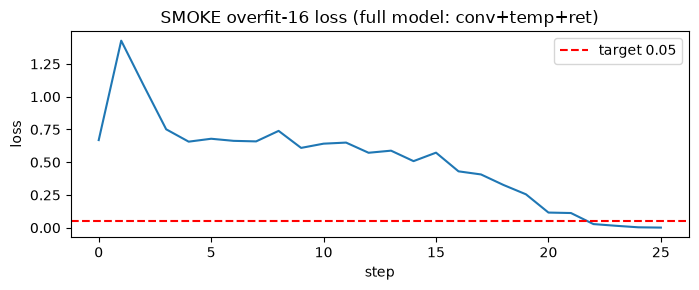

In [2]:
overfit = T.overfit_smoke(cfg, df, corpus, card, n=16, max_steps=150, target_loss=0.05)
plt.figure(figsize=(7, 3))
plt.plot(overfit["losses"])
plt.axhline(0.05, color="r", ls="--", label="target 0.05")
plt.title(f"{SMOKE}overfit-16 loss (full model: conv+temp+ret)")
plt.xlabel("step"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()
assert overfit["passed"], "full model failed to overfit 16 rows — channel wiring bug"

## Train condition 8 on fold 0 (held model object → checkpoint + features)

In [3]:
fold0 = folds[0]
T.set_seed(13)
tok = Tokenize(cfg.encoder_name, cfg.max_len_target, cfg.max_len_context, cfg.max_len_selftext)
assembly = T.Assembly(cfg, df, corpus)
loaders = T.make_loaders(cfg, df, assembly, fold0, tok, seed=13)
train_df = df[df["reddit_fullname"].isin(fold0["train"])]
w = D.class_weights(train_df)
print(f"{SMOKE}fold-0 class weights (neg, pos): ({w[0]:.3f}, {w[1]:.3f})")

model = ContextAwareSarcasmModel(cfg)
hist = T.train_model(model, loaders["train"], loaders["val"], cfg, device, w, log_every=1)
print(f"{SMOKE}best val F1: {hist['best_val_f1']:.4f}")
lam = float(model.temporal_lambda)
print(f"{SMOKE}temporal λ after training: {lam:.4f} "
      f"(init {cfg.temporal_lambda_init}, learnable={cfg.temporal_lambda_learnable} — "
      "thesis baseline keeps it fixed)")

SMOKE fold-0 class weights (neg, pos): (0.558, 4.812)


SMOKE epoch 0: train_loss=0.6191 val_f1=0.0000


SMOKE epoch 1: train_loss=0.6071 val_f1=0.0000
SMOKE best val F1: 0.0000
SMOKE temporal λ after training: 0.1000 (init 0.1, learnable=False — thesis baseline keeps it fixed)


## Per-instance gate values (guide §4.4: log from day one)

The gate distribution by language / record_type is thesis-discussion material.

SMOKE gate value distribution over fold-0 test rows:
      gate_conv  gate_temp  gate_ret
mean   0.470116   0.201997  0.327888
std    0.049848   0.040075  0.017344
min    0.408489   0.138690  0.302508
max    0.558800   0.261674  0.364707

SMOKE mean gates by language:
language  gate_conv  gate_temp  gate_ret
 english   0.500205   0.182589  0.317206
 tagalog   0.471127   0.196960  0.331913
 taglish   0.460624   0.209131  0.330245

SMOKE mean gates by record_type:
record_type  gate_conv  gate_temp  gate_ret
    comment   0.470116   0.201997  0.327888


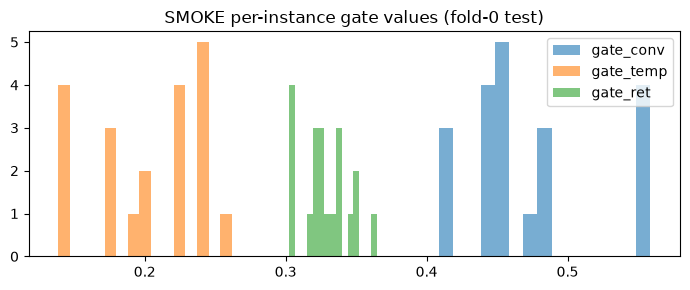

SMOKE fold-0 test: F1=0.0000 (n_pos=0) — tiny-settings smoke only


In [4]:
test_pred = T.predict(model, loaders["test"], device, fp16=cfg.fp16)
meta = pd.DataFrame({
    "reddit_fullname": df["reddit_fullname"],
    "language": D.language(df),
    "record_type": df["record_type"],
    "natural": D.natural_mask(df),
    "resolved_by": df["reliability"].map(lambda r: r["resolved_by"]),
})
test_pred = test_pred.merge(meta, on="reddit_fullname")

gate_cols = [c for c in test_pred.columns if c.startswith("gate_")]
print(f"{SMOKE}gate value distribution over fold-0 test rows:")
print(test_pred[gate_cols].describe().loc[["mean", "std", "min", "max"]])
print(f"\n{SMOKE}mean gates by language:")
print(E.gate_summary(test_pred, by="language").to_string(index=False))
print(f"\n{SMOKE}mean gates by record_type:")
print(E.gate_summary(test_pred, by="record_type").to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3))
for c in gate_cols:
    ax.hist(test_pred[c], bins=15, alpha=0.6, label=c)
ax.set_title(f"{SMOKE}per-instance gate values (fold-0 test)")
ax.legend(); plt.tight_layout(); plt.show()

m = E.safe_metrics(test_pred["y_true"].to_numpy(), test_pred["pred"].to_numpy())
print(f"{SMOKE}fold-0 test: F1={m['f1']:.4f} (n_pos={m['n_pos']}) — tiny-settings smoke only")

## Checkpoint save → reload → identical predictions

In [5]:
ckpt = cfg.cache_path() / "smoke_full_ckpt.pt"
torch.save(model.state_dict(), ckpt)
model2 = ContextAwareSarcasmModel(cfg)
model2.load_state_dict(torch.load(ckpt, weights_only=True))
model2.to(device)
pred2 = T.predict(model2, loaders["test"], device, fp16=cfg.fp16)
assert np.allclose(test_pred["prob"].to_numpy(), pred2["prob"].to_numpy(), atol=1e-6), \
    "reloaded checkpoint predicts differently"
print(f"checkpoint round-trip OK → {ckpt}")

checkpoint round-trip OK → C:\Users\Gio\Documents\GitHub\leische\data\cache\smoke_full_ckpt.pt


## Export fused features + sarcasm flags for notebook 06 (RQ3 stage 2)

`[t ; c_fused]` features for every row, computed with fold-0 retrieval banks.
The RQ3 stage-2 head trains on these FROZEN features (fold-0 train rows only)
so intended-sentiment supervision never touches the sarcasm encoder.

In [6]:
from torch.utils.data import DataLoader

all_names = df["reddit_fullname"].tolist()
retrieval = assembly.fold_retrieval(fold0["train"], all_names)
ds_all = T.SarcasmDataset(df, all_names, assembly, retrieval)
loader_all = DataLoader(ds_all, batch_size=cfg.batch_size, shuffle=False,
                        collate_fn=T.Collator(cfg, tok))
pred_all = T.predict(model, loader_all, device, fp16=cfg.fp16, collect_features=True)
feats = pred_all.attrs["features"]

out = cfg.cache_path() / "smoke_full_features.npz"
np.savez_compressed(out,
                    fullnames=np.array(pred_all["reddit_fullname"], dtype=object),
                    features=feats,
                    prob=pred_all["prob"].to_numpy(),
                    pred=pred_all["pred"].to_numpy())
print(f"saved features {feats.shape} + sarcasm flags for all {len(pred_all)} rows → {out}")
print(f"{SMOKE}flagged sarcastic: {int(pred_all['pred'].sum())} rows "
      "(smoke-quality flags — RQ3 in notebook 06 uses them to exercise the pipeline)")

saved features (100, 512) + sarcasm flags for all 100 rows → C:\Users\Gio\Documents\GitHub\leische\data\cache\smoke_full_features.npz
SMOKE flagged sarcastic: 0 rows (smoke-quality flags — RQ3 in notebook 06 uses them to exercise the pipeline)
